# Importing Required Libraries
These libraries are used for data handling, visualization, model building, and evaluation.

In [ ]:
#Importing libraries

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Hide Warnings
import warnings
warnings.filterwarnings('ignore')


# Uploading the Dataset
We upload the `pima_diabetes_data.csv` file containing the Pima Indians Diabetes dataset.


In [56]:
#upload dataset
from google.colab import files
uploaded = files.upload()

#Loading and Previewing the Dataset
We load the CSV file and view the first few rows.


In [57]:
import pandas as pd

#load dataset
df = pd.read_csv('pima_diabetes_data.csv')

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


#Exploring the Dataset
We check data types, shape, missing values, and basic statistics.


In [58]:
#Explore data to understand its structure

# Basic info
df.info()

# Shape of dataset
print("Dataset contains", df.shape[0], "rows and", df.shape[1], "columns")

# Check missing values
print("\nMissing values:")
print(df.isnull().sum())

# Summary stats
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
Dataset contains 768 rows and 9 columns

Missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
Dia

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


#Class Distribution
We check if the dataset is balanced between diabetic and non-diabetic cases.



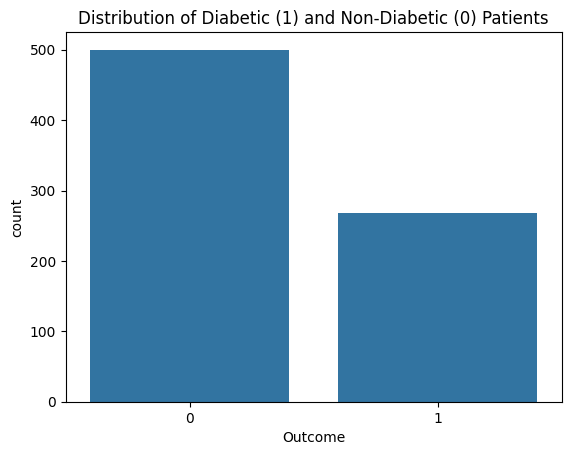

In [59]:
#Visualize Some Data

import matplotlib.pyplot as plt
import seaborn as sns

# Plot class distribution
sns.countplot(x='Outcome', data=df)
plt.title("Distribution of Diabetic (1) and Non-Diabetic (0) Patients")
plt.show()

# Correlation Heatmap
This shows how features relate to each other and to the target.


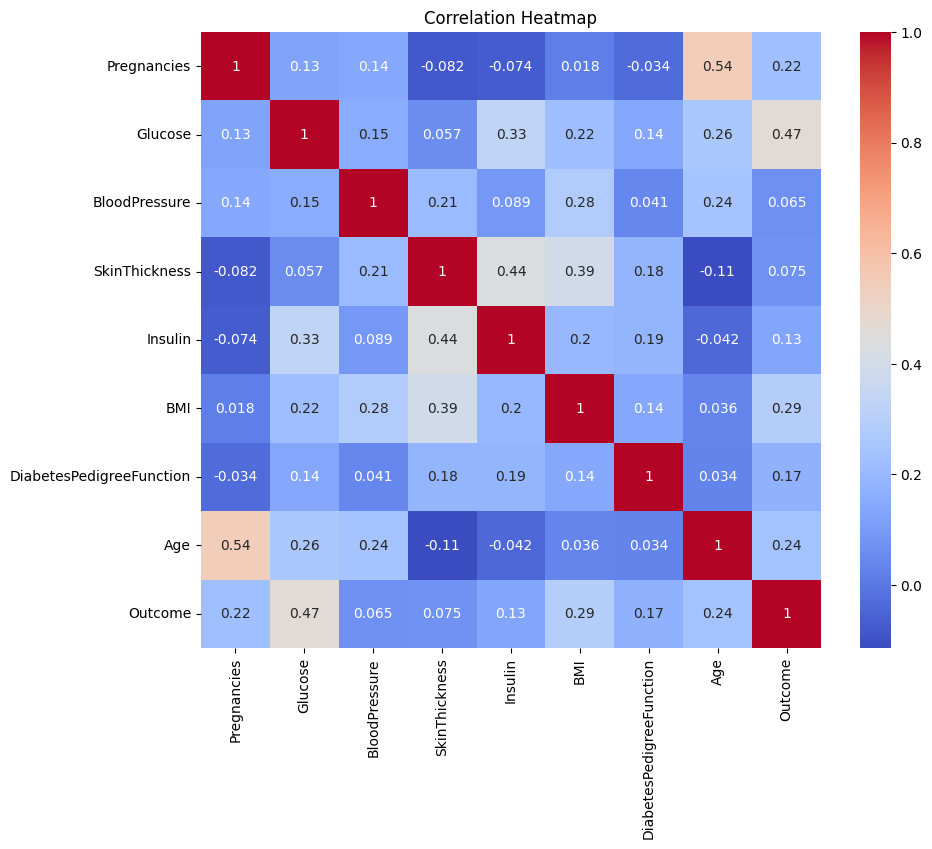

In [60]:
# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

#Data Preprocessing
We handle missing values, replace zeros, fill means, scale features, and split data.


In [61]:
#Replace zeros with NaN

import numpy as np

# Columns where 0 is not valid
cols_with_zero_invalid = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Replace 0 with NaN
df[cols_with_zero_invalid] = df[cols_with_zero_invalid].replace(0, np.nan)

# Show how many NaNs in each column
print(df.isnull().sum())



Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [62]:
# Fill missing values with mean of each column
for col in cols_with_zero_invalid:
    df[col].fillna(df[col].mean(), inplace=True)

# Check if any missing values are left
print(df.isnull().sum())


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [63]:
# Features (X) and Target (y)
X = df.drop('Outcome', axis=1)
y = df['Outcome']


In [64]:
from sklearn.preprocessing import StandardScaler

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [65]:
from sklearn.model_selection import train_test_split

# Split into 80% train and 20% test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Confirm sizes
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (614, 8)
Testing set shape: (154, 8)


#Importing Libraries
we import required libraries for models training and evaluation

In [66]:
#Required Libraries for models & evaluation

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve, classification_report
import matplotlib.pyplot as plt
import seaborn as sns


#Model: Logistic Regression
We train a Logistic Regression classifier and evaluate its performance.


In [67]:
# Train Logistic Regression
lr = LogisticRegression()
lr.fit(X_train, y_train)

#predict on test data
y_pred_lr = lr.predict(X_test)

#print classification report
print("Logistic Regression Report:\n")
print(classification_report(y_test, y_pred_lr))


Logistic Regression Report:

              precision    recall  f1-score   support

           0       0.80      0.83      0.81        99
           1       0.67      0.62      0.64        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.73       154
weighted avg       0.75      0.75      0.75       154



# Model: KNN
We train a KNN classifier and evaluate its performance.


In [68]:
# Train KNN
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

#predict on test data
y_pred_knn = knn.predict(X_test)

#print classification report
print("KNN Report:\n")
print(classification_report(y_test, y_pred_knn))


KNN Report:

              precision    recall  f1-score   support

           0       0.83      0.75      0.79        99
           1       0.62      0.73      0.67        55

    accuracy                           0.74       154
   macro avg       0.72      0.74      0.73       154
weighted avg       0.75      0.74      0.74       154



# Model: Decision Tree
We train a Decision Tree classifier and evaluate its performance.


In [69]:
# Train Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

#predict on test data
y_pred_dt = dt.predict(X_test)

#print classification report
print("Decision Tree Report:\n")
print(classification_report(y_test, y_pred_dt))


Decision Tree Report:

              precision    recall  f1-score   support

           0       0.79      0.78      0.78        99
           1       0.61      0.62      0.61        55

    accuracy                           0.72       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.72      0.72      0.72       154



# Model: Random Forest
We train a Random Forest classifier and evaluate its performance.


In [70]:
# Train Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

#predict on test data
y_pred_rf = rf.predict(X_test)

#print classification report
print("Random Forest Report:\n")
print(classification_report(y_test, y_pred_rf))


Random Forest Report:

              precision    recall  f1-score   support

           0       0.81      0.81      0.81        99
           1       0.65      0.65      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154



#  Model: SVM
We train a SVM classifier and evaluate its performance.


In [71]:
# Train SVM
svm = SVC(probability=True)  # Enable ROC curve
svm.fit(X_train, y_train)

#predict on test data
y_pred_svm = svm.predict(X_test)

#print classification report
print("SVM Report:\n")
print(classification_report(y_test, y_pred_svm))


SVM Report:

              precision    recall  f1-score   support

           0       0.79      0.85      0.82        99
           1       0.68      0.58      0.63        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154



#  Confusion Matrix for Random Forest


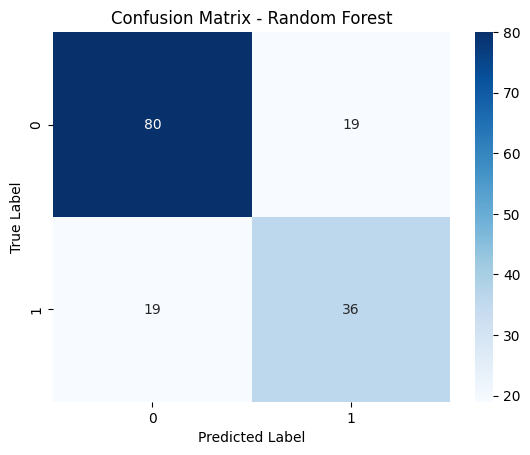

In [72]:
from sklearn.metrics import confusion_matrix

# Get confusion matrix for Random Forest
cm = confusion_matrix(y_test, y_pred_rf)

# Plot
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


#  ROC Curves for All Models
This visualizes the performance tradeoff between sensitivity and specificity.


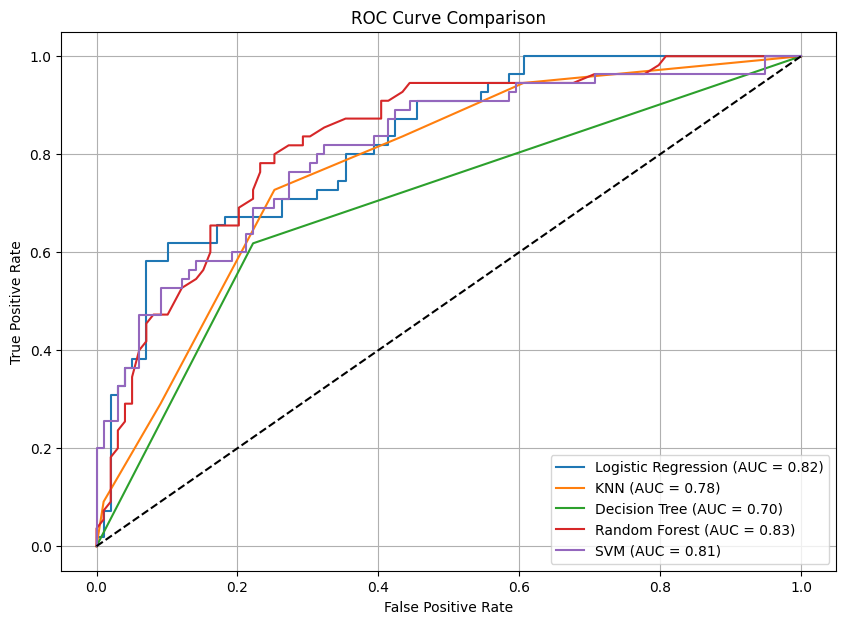

In [73]:
from sklearn.metrics import roc_curve, auc

# Predict probabilities
y_prob_lr = lr.predict_proba(X_test)[:,1]
y_prob_knn = knn.predict_proba(X_test)[:,1]
y_prob_dt = dt.predict_proba(X_test)[:,1]
y_prob_rf = rf.predict_proba(X_test)[:,1]
y_prob_svm = svm.predict_proba(X_test)[:,1]

# Plot ROC curves
plt.figure(figsize=(10,7))

models = {
    'Logistic Regression': y_prob_lr,
    'KNN': y_prob_knn,
    'Decision Tree': y_prob_dt,
    'Random Forest': y_prob_rf,
    'SVM': y_prob_svm
}

for name, y_prob in models.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

# Plot baseline
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


#  Artificial Neural Network (ANN)
We build and evaluate a neural network using Keras (TensorFlow).


In [74]:
#import libraries for ANN

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


In [75]:
# Build the ANN
model = Sequential()

# Input layer + First hidden layer
model.add(Dense(12, activation='relu', input_shape=(8,)))

# Second hidden layer (optional, for better learning)
model.add(Dense(8, activation='relu'))

# Output layer
model.add(Dense(1, activation='sigmoid'))  # sigmoid for binary output


In [76]:
# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [77]:
# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=10, validation_data=(X_test, y_test), verbose=1)


Epoch 1/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5683 - loss: 0.6901 - val_accuracy: 0.6688 - val_loss: 0.6686
Epoch 2/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6623 - loss: 0.6377 - val_accuracy: 0.7013 - val_loss: 0.6196
Epoch 3/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7296 - loss: 0.5663 - val_accuracy: 0.7078 - val_loss: 0.5707
Epoch 4/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7653 - loss: 0.5097 - val_accuracy: 0.7532 - val_loss: 0.5358
Epoch 5/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7656 - loss: 0.4933 - val_accuracy: 0.7532 - val_loss: 0.5193
Epoch 6/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7836 - loss: 0.4566 - val_accuracy: 0.7597 - val_loss: 0.5092
Epoch 7/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7718 - loss: 0.4661 - val_accuracy: 0.7597 - val_loss: 0.5053
Epoch 8/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7462 - loss: 0.4685 - val_accuracy: 0.7468 - v

In [78]:
# Evaluate on test set
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy (ANN): {:.2f}%".format(accuracy * 100))


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7064 - loss: 0.6317 
Test Accuracy (ANN): 75.32%


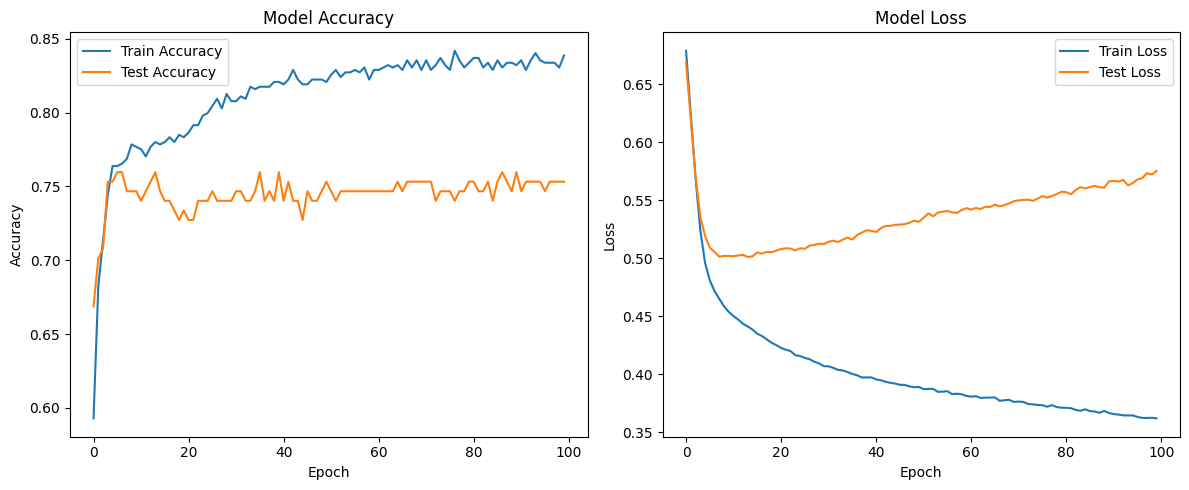

In [79]:
# Plot training accuracy and loss
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()
